# Week 5 Lab: Evaluation & Experiment Design

**Self-Paced Lab**

1. Learn why accuracy alone is dangerous and pick the right metric for a given problem
2. Catch and fix data leakage in a pipeline
3. Run a proper cross-validation
4. Analyze a simulated A/B test and make a ship/don't-ship decision
5. Track experiments in a structured way


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from scipy import stats

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print("Setup complete ✓")

Setup complete ✓


---
## Part 1: Metrics That Matter

### The Accuracy Trap

Let's create a realistic fraud detection dataset: heavily imbalanced

In [37]:
# Create an imbalanced fraud detection dataset
# Only ~0.5% of transactions are fraudulent
n_samples = 20000
n_fraud = 100  # 0.5% fraud rate

X, y = make_classification(
    n_samples=n_samples,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    weights=[1 - n_fraud/n_samples, n_fraud/n_samples],
    flip_y=0.02,
    random_state=42
)

print(f"Total transactions: {len(y)}")
print(f"Legitimate: {(y == 0).sum()} ({(y == 0).mean():.1%})")
print(f"Fraudulent: {(y == 1).sum()} ({(y == 1).mean():.1%})")

Total transactions: 20000
Legitimate: 19713 (98.6%)
Fraudulent: 287 (1.4%)


In [38]:
# The "amazing" model: just predict everything as legitimate
y_pred_naive = np.zeros_like(y)

print(f"Accuracy of always predicting 'not fraud': {accuracy_score(y, y_pred_naive):.1%}")
print(f"\nBut how many frauds did we catch? {recall_score(y, y_pred_naive):.1%}")
print(f"\n-> This model catches ZERO fraud. 'Accuracy' is meaningless here.")

Accuracy of always predicting 'not fraud': 98.6%

But how many frauds did we catch? 0.0%

-> This model catches ZERO fraud. 'Accuracy' is meaningless here.


### Exercise 1.1: Compute the Right Metrics

Train a RandomForestClassifier on this fraud dataset. Compute accuracy, precision, recall, F1, and AUC-ROC. Then answer the questions below.

In [39]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TODO: Train a RandomForestClassifier (use class_weight='balanced' to handle imbalance)
# model = ...
# model.fit(...)
# y_pred = ...
# y_proba = ...  # hint: model.predict_proba(X_test)[:, 1]

# YOUR CODE HERE
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


In [40]:
# TODO: Compute and print the following metrics:
# - Accuracy
# - Precision
# - Recall
# - F1 Score
# - AUC-ROC (use y_proba, not y_pred)

# YOUR CODE HERE
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {accuracy:.1%}")
print(f"Precision: {precision:.1%}")
print(f"Recall: {recall:.1%}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

Accuracy: 98.6%
Precision: 100.0%
Recall: 1.8%
F1 Score: 0.0345
AUC-ROC: 0.6615


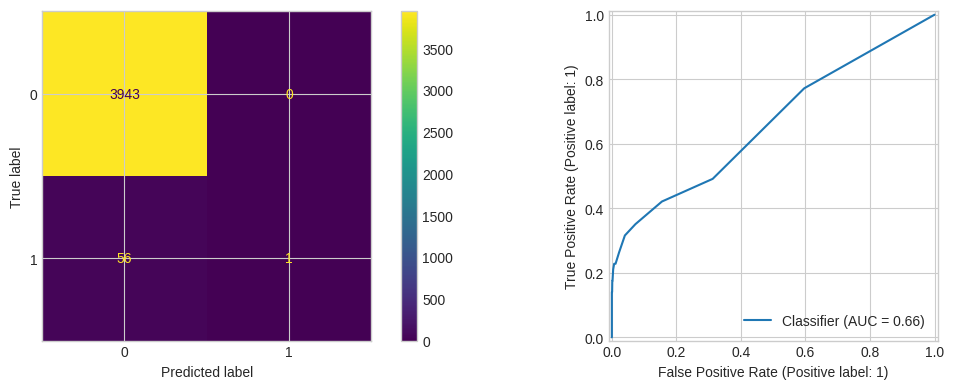

In [8]:
# TODO: Plot the confusion matrix and the ROC curve
# hint: ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ...)
# hint: RocCurveDisplay.from_predictions(y_test, y_proba, ...)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# YOUR CODE HERE
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])

plt.tight_layout()
plt.show()

### Exercise 1.2: Which Metric Matters?

For each scenario below, write which metric you'd prioritize and briefly why:

1. **Airport security screening** (detecting prohibited items in bags):


2. **Email spam filter** (filtering spam from inbox):


3. **Product recommendation** (suggesting items a user might buy):


4. **Autonomous driving** (detecting pedestrians):

*Think about: What's the cost of a false positive vs. a false negative?*

---
## Part 2: Catch the Leak

Below is a machine learning pipeline that looks reasonable but contains **data leakage**. Your job is to find it and fix it.

### The Leaky Pipeline

In [18]:
# Generate a dataset for this exercise
X_leak, y_leak = make_classification(
    n_samples=2000, n_features=15, n_informative=8,
    n_redundant=3, random_state=42
)

# ========== LEAKY PIPELINE (DO NOT MODIFY THIS CELL) ==========

# Step 1: Scale ALL the data
scaler = StandardScaler()
X_leak_scaled = scaler.fit_transform(X_leak)  # Fitting on ALL data

# Step 2: Now split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_leak_scaled, y_leak, test_size=0.2, random_state=42
)

# Step 3: Train and evaluate
model_leaky = LogisticRegression(random_state=42)
model_leaky.fit(X_tr, y_tr)
leaky_score = model_leaky.score(X_te, y_te)
print(f"Leaky pipeline accuracy: {leaky_score:.4f}")

Leaky pipeline accuracy: 0.7125


### Exercise 2.1: What's the Leak?

**Question:** What's wrong with the pipeline above? Why does it cause data leakage? Write your answer below.

### Exercise 2.2: Fix It

Rewrite the pipeline without the leak. Use `sklearn.pipeline.Pipeline` to keep it clean.

In [41]:
# TODO: Write the CORRECT pipeline
# 1. Split FIRST (use the original X_leak, y_leak: not the scaled version)
# 2. Use Pipeline so the scaler only sees training data
# hint: Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(random_state=42))])

# YOUR CODE HERE
X_tr, X_te, y_tr, y_te = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42
)
pipeline = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(random_state=42))])
pipeline.fit(X_tr, y_tr)
score = pipeline.score(X_te, y_te)
print(f"Fixed pipeline accuracy: {score:.4f}")


Fixed pipeline accuracy: 0.7125


### Exercise 2.3: Cross-Validation

Use `cross_val_score` with `StratifiedKFold(n_splits=5)` to get a more robust estimate of your model's performance. Report the mean and standard deviation.

In [20]:
# TODO: Run 5-fold stratified cross-validation on the ORIGINAL (unscaled) data
# Use the Pipeline you built above
# hint: cross_val_score(pipeline, X_leak, y_leak, cv=StratifiedKFold(n_splits=5), scoring='accuracy')

# YOUR CODE HERE
scores = cross_val_score(pipeline, X_leak, y_leak, cv=StratifiedKFold(n_splits=5), scoring='accuracy')
print(f"Cross-validation scores: {scores}")


Cross-validation scores: [0.7125 0.7125 0.7    0.745  0.7025]


---
## Part 3: A/B Testing

### Scenario

You work at an e-commerce startup. Your team built a new ML-powered recommendation engine (**Model B**) to replace the current popularity-based system (**Model A**). Before rolling it out to everyone, you run an A/B test:

- **Group A (Control):** 5,000 users see recommendations from the popularity-based model
- **Group B (Treatment):** 5,000 users see recommendations from the ML model
- **Metric:** Conversion rate (did the user purchase something? yes/no)
- **Hypothesis:** Model B increases conversion rate

Let's simulate this experiment.

In [21]:
# Simulate A/B test data
np.random.seed(42)

# True conversion rates (unknown to us in practice)
true_rate_A = 0.032  # 3.2% conversion - typical for e-commerce
true_rate_B = 0.038  # 3.8% conversion - the ML model is slightly better

n_users_A = 5000
n_users_B = 5000

# Simulate: each user either converts (1) or doesn't (0)
conversions_A = np.random.binomial(1, true_rate_A, n_users_A)
conversions_B = np.random.binomial(1, true_rate_B, n_users_B)

# Build a DataFrame (this is what you'd get from your analytics system)
df_ab = pd.DataFrame({
    'user_id': range(n_users_A + n_users_B),
    'group': ['A'] * n_users_A + ['B'] * n_users_B,
    'converted': np.concatenate([conversions_A, conversions_B])
})

print("A/B Test Data Sample:")
print(df_ab.head(10))
print(f"\nTotal users: {len(df_ab)}")
print(f"Group A: {n_users_A}, Group B: {n_users_B}")

A/B Test Data Sample:
   user_id group  converted
0        0     A          0
1        1     A          0
2        2     A          0
3        3     A          0
4        4     A          0
5        5     A          0
6        6     A          0
7        7     A          0
8        8     A          0
9        9     A          0

Total users: 10000
Group A: 5000, Group B: 5000


### Exercise 3.1: Compute Conversion Rates

Calculate the conversion rate for each group and the absolute and relative lift.

In [24]:
# TODO: Calculate conversion rates for each group
# rate_A = ...
# rate_B = ...
# absolute_lift = rate_B - rate_A
# relative_lift = (rate_B - rate_A) / rate_A

# YOUR CODE HERE
rate_A = df_ab[df_ab['group'] == 'A']['converted'].mean()
rate_B = df_ab[df_ab['group'] == 'B']['converted'].mean()
absolute_lift = rate_B - rate_A
relative_lift = (rate_B - rate_A) / rate_A

print(f"Group A Conversion Rate: {rate_A:.4%}")
print(f"Group B Conversion Rate: {rate_B:.4%}")
print(f"Absolute Lift: {absolute_lift:.4%}")
print(f"Relative Lift: {relative_lift:.2%}")

Group A Conversion Rate: 3.1400%
Group B Conversion Rate: 3.3000%
Absolute Lift: 0.1600%
Relative Lift: 5.10%


### Exercise 3.2: Is It Statistically Significant?

A difference in conversion rates doesn't mean much if it could be due to random chance. Let's test it.

We'll use a **two-proportion z-test** (the standard approach for A/B tests on binary outcomes).

In [26]:
def two_proportion_z_test(conversions_a, conversions_b, n_a, n_b):
    """
    Two-proportion z-test for A/B testing.
    H0: p_A = p_B (no difference)
    H1: p_A ≠ p_B (two-sided)

    Returns: z-statistic, p-value
    """
    p_a = conversions_a / n_a
    p_b = conversions_b / n_b

    # Pooled proportion under H0
    p_pool = (conversions_a + conversions_b) / (n_a + n_b)

    # Standard error
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_a + 1/n_b))

    # Z-statistic
    z = (p_b - p_a) / se

    # Two-sided p-value
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    return z, p_value


# TODO: Use the function above to test your A/B results
# conversions_total_A = df_ab[df_ab['group'] == 'A']['converted'].sum()
# conversions_total_B = ...
# z_stat, p_value = two_proportion_z_test(...)

# YOUR CODE HERE
confusion_total_A = df_ab[df_ab['group'] == 'A']['converted'].sum()
confusion_total_B = df_ab[df_ab['group'] == 'B']['converted'].sum()
z_stat, p_value = two_proportion_z_test(confusion_total_A, confusion_total_B, n_users_A, n_users_B)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")


Z-statistic: 0.4532
P-value: 0.6504


### Exercise 3.3: Confidence Interval

A p-value tells you whether the effect is "real," but not how big it is. Compute a 95% confidence interval for the difference in conversion rates.

In [29]:
# TODO: Compute the 95% confidence interval for (rate_B - rate_A)
#
# Formula:
#   diff = rate_B - rate_A
#   se_diff = sqrt(rate_A*(1-rate_A)/n_A + rate_B*(1-rate_B)/n_B)
#   ci_lower = diff - 1.96 * se_diff
#   ci_upper = diff + 1.96 * se_diff

# YOUR CODE HERE
diff = rate_B - rate_A
se_diff = np.sqrt(rate_A * (1 - rate_A) / n_users_A + rate_B * (1 - rate_B) / n_users_B)
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print(f"95% Confidence Interval: ({ci_lower:.4%}, {ci_upper:.4%})")

95% Confidence Interval: (-0.5320%, 0.8520%)


### Exercise 3.4: Sample Size Planning

**Before** running an A/B test, you should figure out how many users you need. This prevents both:
- Stopping too early (underpowered test, missing a real effect)
- Running too long (wasting traffic on a test you could have decided already)

Use the function below to explore how sample size changes with parameters.

In [30]:
def required_sample_size(baseline_rate, min_detectable_effect, alpha=0.05, power=0.80):
    """
    Estimate required sample size per group for a two-proportion test.

    Parameters:
    - baseline_rate: current conversion rate (e.g., 0.032)
    - min_detectable_effect: smallest absolute lift you care about (e.g., 0.005)
    - alpha: significance level (default 0.05)
    - power: statistical power (default 0.80)

    Returns: n per group
    """
    p1 = baseline_rate
    p2 = baseline_rate + min_detectable_effect

    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)

    p_avg = (p1 + p2) / 2
    n = ((z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) +
          z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2) / (p2 - p1) ** 2

    return int(np.ceil(n))


# Example
n_needed = required_sample_size(baseline_rate=0.032, min_detectable_effect=0.005)
print(f"To detect a 0.5pp lift from a 3.2% baseline:")
print(f"  → Need {n_needed:,} users PER GROUP")
print(f"  → Total: {2 * n_needed:,} users")

To detect a 0.5pp lift from a 3.2% baseline:
  → Need 20,915 users PER GROUP
  → Total: 41,830 users


In [33]:
# TODO: Explore how sample size changes with different parameters
# Try:
#   a) min_detectable_effect = 0.01 (1 percentage point lift)
#   b) min_detectable_effect = 0.002 (0.2 percentage point lift)
#   c) power = 0.90 instead of 0.80
#
# Question: Why does detecting a smaller effect require vastly more users?
# Your answer: ...

# YOUR CODE HERE
min_detectable_effect = 0.01
n_needed = required_sample_size(baseline_rate=0.032, min_detectable_effect=min_detectable_effect)
print(f"To detect a 1pp lift from a 3.2% baseline:")
print(f"  → Need {n_needed:,} users PER GROUP")
print(f"  → Total: {2 * n_needed:,} users")

min_detectable_effect = 0.002
n_needed = required_sample_size(baseline_rate=0.032, min_detectable_effect=min_detectable_effect)
print(f"To detect a 0.2pp lift from a 3.2% baseline:")
print(f"  → Need {n_needed:,} users PER GROUP")
print(f"  → Total: {2 * n_needed:,} users")


To detect a 1pp lift from a 3.2% baseline:
  → Need 5,593 users PER GROUP
  → Total: 11,186 users
To detect a 0.2pp lift from a 3.2% baseline:
  → Need 125,232 users PER GROUP
  → Total: 250,464 users


### Exercise 3.5: The Decision

You're in the meeting with your startup's CEO. Based on your analysis, answer:

1. **Is Model B statistically significantly better than Model A?**


2. **What's the estimated improvement, and how confident are you in the range?**

3. **Would you recommend shipping Model B to all users? Why or why not?**
   - (Consider: Is the effect practically meaningful? Cost of switching? Risks?)

4. **What would you want to test next?**


### Exercise 3.6: A Second A/B Test - The Tricky Case

Your colleague ran another A/B test: testing a new checkout page design. Here's the data:

In [34]:
# A/B test 2: New checkout page
np.random.seed(123)

# Smaller sample, smaller effect
conversions_A2 = np.random.binomial(1, 0.045, 800)   # 4.5% baseline
conversions_B2 = np.random.binomial(1, 0.052, 800)   # 5.2% (small improvement)

rate_A2 = conversions_A2.mean()
rate_B2 = conversions_B2.mean()

print(f"Checkout A/B Test:")
print(f"  Group A (old checkout): {rate_A2:.2%} conversion ({conversions_A2.sum()}/{len(conversions_A2)})")
print(f"  Group B (new checkout): {rate_B2:.2%} conversion ({conversions_B2.sum()}/{len(conversions_B2)})")
print(f"  Relative lift: {(rate_B2 - rate_A2) / rate_A2:+.1%}")

Checkout A/B Test:
  Group A (old checkout): 4.50% conversion (36/800)
  Group B (new checkout): 5.75% conversion (46/800)
  Relative lift: +27.8%


In [35]:
# TODO: Run the significance test on this second A/B test
# Is it significant? What do you conclude?
# What would you recommend: ship, don't ship, or keep testing?

# YOUR CODE HERE
z_stat, p_value = two_proportion_z_test(conversions_A2.sum(), conversions_B2.sum(), len(conversions_A2), len(conversions_B2))

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 1.1337
P-value: 0.2569


---
## Part 4: Experiment Tracking

When you're iterating on a model (trying different algorithms, hyperparameters, feature sets) it's easy to lose track of what you tried and what worked.

**The minimal habit:** log every experiment to a structured format.

### Exercise 4.1: Track a Hyperparameter Search

Use the fraud detection dataset from Part 1. Try several model configurations and track the results.

In [42]:
# We'll use the fraud dataset from Part 1
# X_train, X_test, y_train, y_test are already defined

# Define experiments to try
experiments = [
    {"name": "LogReg (default)",      "model": LogisticRegression(random_state=42, max_iter=1000)},
    {"name": "LogReg (balanced)",     "model": LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')},
    {"name": "RF (100 trees)",        "model": RandomForestClassifier(n_estimators=100, random_state=42)},
    {"name": "RF (balanced)",         "model": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')},
    {"name": "GBM (default)",         "model": GradientBoostingClassifier(n_estimators=100, random_state=42)},
    {"name": "GBM (200 trees, d=5)",  "model": GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42)},
]

# TODO: Run each experiment, collect results in a list of dicts
# For each: name, accuracy, precision, recall, f1, auc_roc
#
# hint:
# results = []
# for exp in experiments:
#     pipe = Pipeline([('scaler', StandardScaler()), ('model', exp['model'])])
#     pipe.fit(X_train, y_train)
#     y_p = pipe.predict(X_test)
#     y_pr = pipe.predict_proba(X_test)[:, 1]
#     results.append({...})

# YOUR CODE HERE
results = []
for exp in experiments:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', exp['model'])])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_proba)

    results.append({
        'name': exp['name'],
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc
    })


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
# TODO: Create a DataFrame from your results and display it
# Sort by F1 score (fraud detection: we care about both precision and recall)

# YOUR CODE HERE
results_df = pd.DataFrame(results)
results_df.sort_values(by='f1', ascending=False, inplace=True)
results_df


,name,accuracy,precision,recall,f1,auc_roc
5,"GBM (200 trees, d=5)",0.98100,0.086957,0.035088,0.050000,0.689866
1,LogReg (balanced),0.65150,0.020101,0.491228,0.038621,0.593176
0,LogReg (default),0.98600,1.000000,0.017544,0.034483,0.560736
3,RF (balanced),0.98600,1.000000,0.017544,0.034483,0.661548
4,GBM (default),0.98025,0.041667,0.017544,0.024691,0.650260
2,RF (100 trees),0.98575,0.000000,0.000000,0.000000,0.628734


<Axes: xlabel='name'>

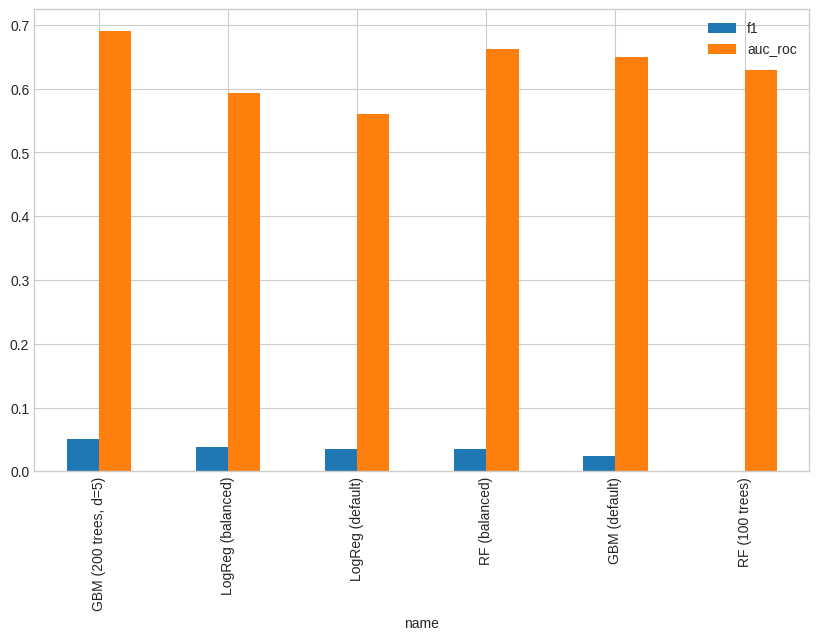

In [44]:
# TODO: Visualize: bar chart comparing F1 and AUC-ROC across experiments
# hint: results_df.plot(...)

# YOUR CODE HERE
results_df.plot(kind='bar', x='name', y=['f1', 'auc_roc'], figsize=(10, 6))

### What This Looks Like in Practice (MLflow / W&B)

In a real project you'd use a dedicated tool. Here's what the same tracking looks like with MLflow (conceptual; you don't need to install it):

```python
import mlflow

mlflow.set_experiment("fraud-detection")

for exp in experiments:
    with mlflow.start_run(run_name=exp['name']):
        pipe = Pipeline([('scaler', StandardScaler()), ('model', exp['model'])])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        mlflow.log_params(exp['model'].get_params())
        mlflow.log_metric("f1", f1_score(y_test, y_pred))
        mlflow.log_metric("auc_roc", roc_auc_score(y_test, y_proba))
        mlflow.sklearn.log_model(pipe, "model")
```

This gives you:
- A searchable history of all experiments
- Parameter and metric comparison across runs
- Model artifacts you can reload later
- Shareable dashboards for your team

**Weights & Biases** works similarly but is cloud-hosted: great for collaboration and automatic visualizations. Both are free for personal / academic use.